In [1]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
import seaborn as sns
from sklearn.ensemble import IsolationForest
import joblib
os.chdir('Resources/')

In [2]:
df = pd.read_csv('4_Hashed_Data.csv')

X = df.drop(['HeartDisease'], axis='columns')
Y = df[['HeartDisease']]

Accuracy for train size 0.1: 0.7873626373626373
Accuracy for train size 0.2: 0.8167490729295427
Accuracy for train size 0.3: 0.8382197103496998
Accuracy for train size 0.4: 0.8586732591676968
Accuracy for train size 0.5: 0.8921859545004945
Accuracy for train size 0.6: 0.9128553770086527
Accuracy for train size 0.7: 0.9324546952224053
Accuracy for train size 0.8: 0.9480840543881335
Accuracy for train size 0.9: 0.9777777777777777


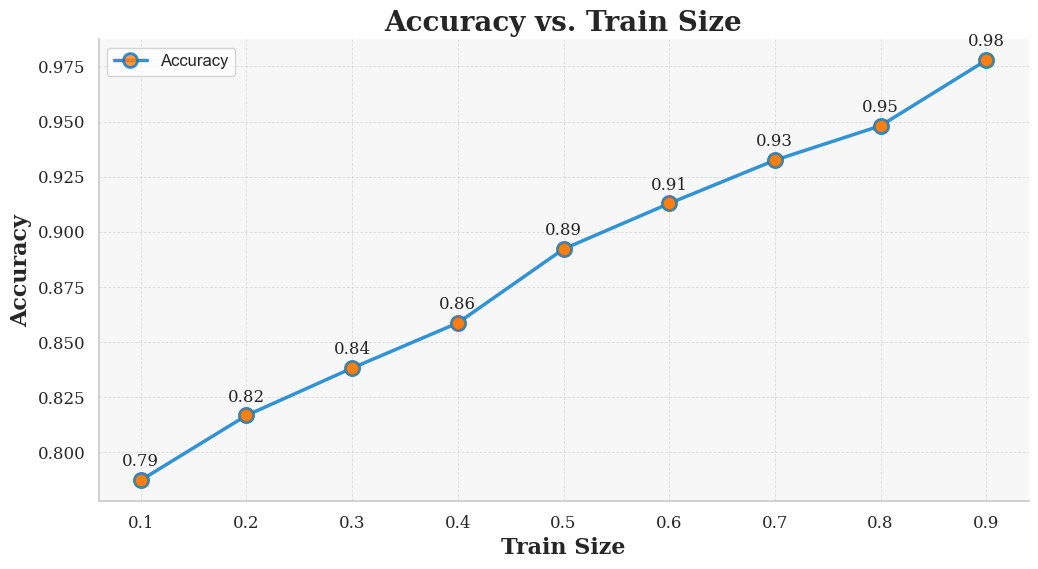

In [10]:
seed = 518

train_sizes = np.linspace(0.1, 0.9, 9)
accuracies_rf = []
model_rf = None

for train_size in train_sizes:
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=seed)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    rf = RandomForestClassifier(random_state=seed)
    model_rf = rf.fit(X_train, Y_train.values.ravel()) 
    
    pred = model_rf.predict(X_test)
    accuracy_rf = accuracy_score(Y_test, pred)
    
    accuracies_rf.append(accuracy_rf)
    print(f"Accuracy for train size {train_size:.1f}: {accuracy_rf}")

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, accuracies_rf, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', family='serif')
plt.title('Accuracy vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(accuracies_rf):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], accuracies_rf[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['Accuracy'], fontsize=12)

sns.despine()

for i, txt in enumerate(accuracies_rf):
    plt.plot(train_sizes[i], accuracies_rf[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], accuracies_rf[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

Accuracy for train size 0.1: 0.7087912087912088
Accuracy for train size 0.2: 0.7583436341161929
Accuracy for train size 0.3: 0.7975980219003885
Accuracy for train size 0.4: 0.8084054388133498
Accuracy for train size 0.5: 0.8382789317507419
Accuracy for train size 0.6: 0.8597033374536465
Accuracy for train size 0.7: 0.886326194398682
Accuracy for train size 0.8: 0.9060568603213844
Accuracy for train size 0.9: 0.9506172839506173


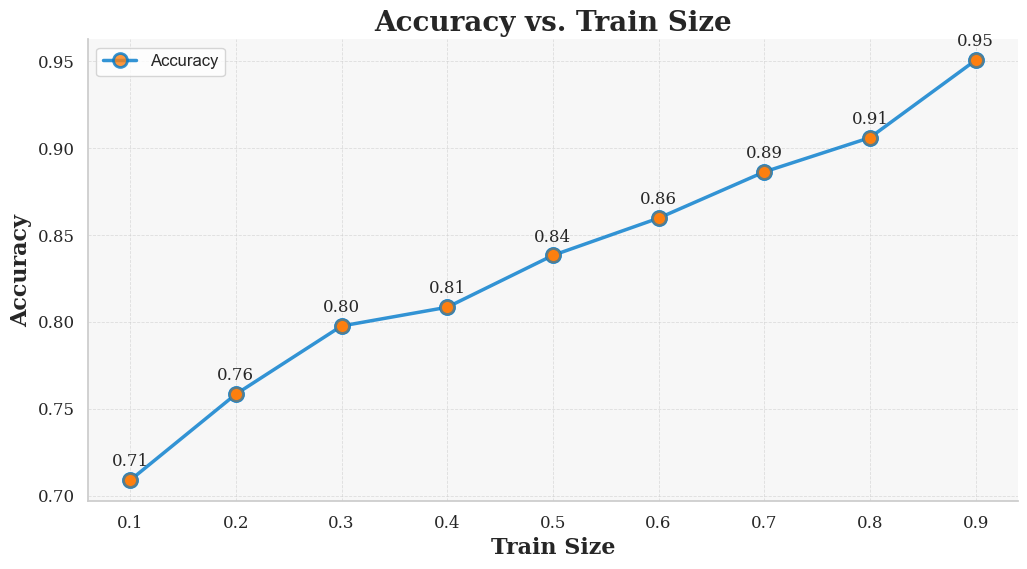

In [11]:
seed = 3089

train_sizes = np.linspace(0.1, 0.9, 9)
accuracies_pca = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=seed)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    pca = PCA(n_components=9)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    rf_pca = RandomForestClassifier(random_state=seed)
    rf_pca.fit(X_train_pca, Y_train.values.ravel())
    
    pred_pca = rf_pca.predict(X_test_pca)
    accuracy_pca = accuracy_score(Y_test, pred_pca)
    
    accuracies_pca.append(accuracy_pca)
    print(f"Accuracy for train size {train_size:.1f}: {accuracy_pca}")

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, accuracies_pca, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', family='serif')
plt.title('Accuracy vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(accuracies_pca):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], accuracies_pca[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['Accuracy'], fontsize=12)

sns.despine()

for i, txt in enumerate(accuracies_pca):
    plt.plot(train_sizes[i], accuracies_pca[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], accuracies_pca[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

Accuracy for train size 0.1: 0.7884615384615384
Accuracy for train size 0.2: 0.8254017305315204
Accuracy for train size 0.3: 0.8466972801130342
Accuracy for train size 0.4: 0.8677379480840544
Accuracy for train size 0.5: 0.8724035608308606
Accuracy for train size 0.6: 0.9023485784919654
Accuracy for train size 0.7: 0.929159802306425
Accuracy for train size 0.8: 0.9517923362175525
Accuracy for train size 0.9: 0.9753086419753086


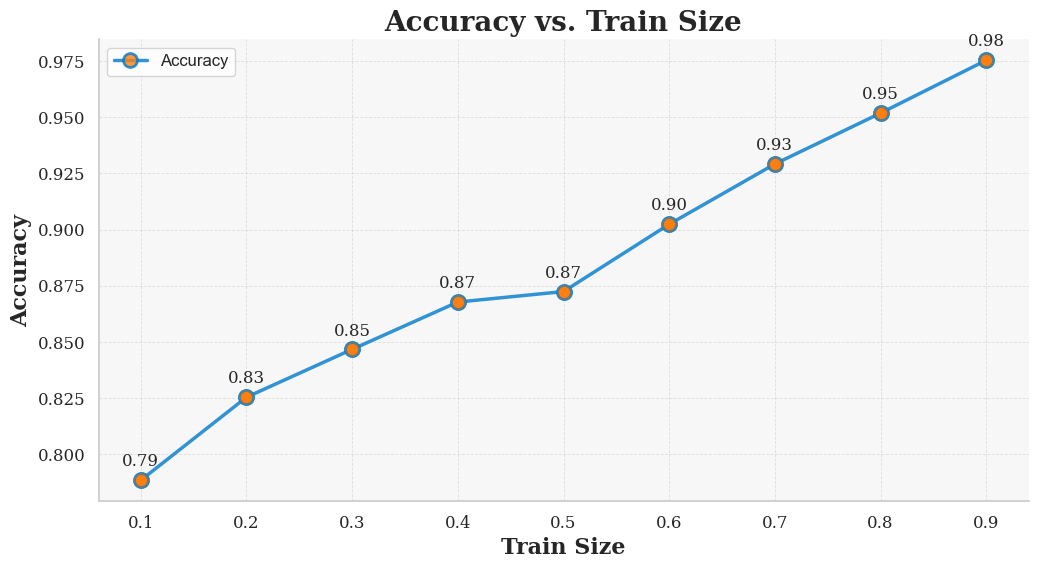

In [5]:
seed = 310

train_sizes = np.linspace(0.1, 0.9, 9)
accuracies_isolation = []

for i, train_size in enumerate(train_sizes):
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=train_size, random_state=seed)

    clf = IsolationForest(contamination=0.08, random_state=seed)
    outliers = clf.fit_predict(X_train)
    X_train = X_train[outliers == 1]
    Y_train = Y_train[outliers == 1]

    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_selected = X_train.drop(to_drop, axis=1)
    X_test_selected = X_test.drop(to_drop, axis=1)

    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf_classifier.fit(X_train_selected, Y_train.values.ravel())

    Y_pred = rf_classifier.predict(X_test_selected)

    accuracy_isolation = accuracy_score(Y_test, Y_pred)

    accuracies_isolation.append(accuracy_isolation)
    print(f"Accuracy for train size {train_size:.1f}: {accuracy_isolation}")

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, accuracies_isolation, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', family='serif')
plt.title('Accuracy vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(accuracies_isolation):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], accuracies_isolation[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['Accuracy'], fontsize=12)

sns.despine()

for i, txt in enumerate(accuracies_isolation):
    plt.plot(train_sizes[i], accuracies_isolation[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], accuracies_isolation[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy for train size 0.1: 0.7304945054945055


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy for train size 0.2: 0.7469097651421508


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy for train size 0.7: 0.8805601317957167


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy for train size 0.8: 0.899876390605686


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy for train size 0.9: 0.9358024691358025


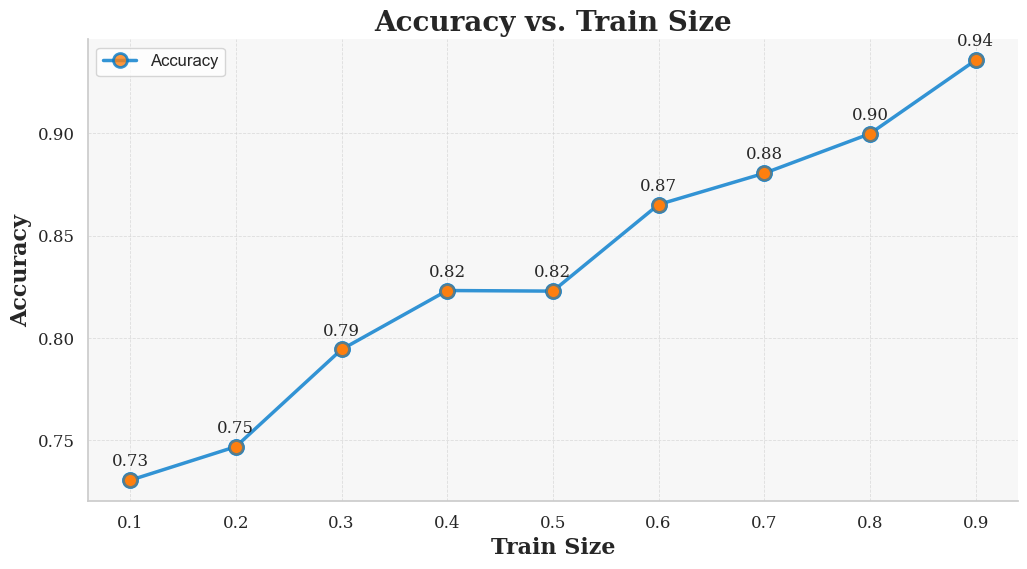

In [13]:
accuracies_lstm = []
seed = 637

for i in range(1, 10):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=i * 0.1, random_state=seed)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_reshaped = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_reshaped = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

    model = Sequential()
    model.add(LSTM(11, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
    model.add(Dropout(0.01 * 4))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=1/75)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    model.fit(X_train_reshaped, Y_train, epochs=217, batch_size=10000, verbose=0)

    X_train_features = model.predict(X_train_reshaped)
    X_test_features = model.predict(X_test_reshaped)

    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf_classifier.fit(X_train_features, Y_train.values.ravel())

    Y_pred = rf_classifier.predict(X_test_features)
    accuracy_lstm = accuracy_score(Y_test, Y_pred)

    accuracies_lstm.append(accuracy_lstm)
    print(f"Accuracy for train size {0.1 * i:.1f}: {accuracy_lstm}")

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, accuracies_lstm, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.8)

plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', family='serif')
plt.title('Accuracy vs. Train Size', fontsize=20, fontweight='bold', family='serif')

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
plt.gca().set_facecolor('#f7f7f7')

for i, txt in enumerate(accuracies_lstm):
    plt.annotate(f"{txt:.2f}", (train_sizes[i], accuracies_lstm[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, family='serif')

plt.xticks(fontsize=12, family='serif')
plt.yticks(fontsize=12, family='serif')

plt.legend(['Accuracy'], fontsize=12)

sns.despine()

for i, txt in enumerate(accuracies_lstm):
    plt.plot(train_sizes[i], accuracies_lstm[i], marker='o', markersize=10, color='#ff7f0e', alpha=0.9)
    plt.plot(train_sizes[i], accuracies_lstm[i], marker='o', markersize=10, color='#007acc', markerfacecolor='#ff7f0e', markeredgewidth=2, markeredgecolor='#007acc', alpha=0.6)

plt.show()

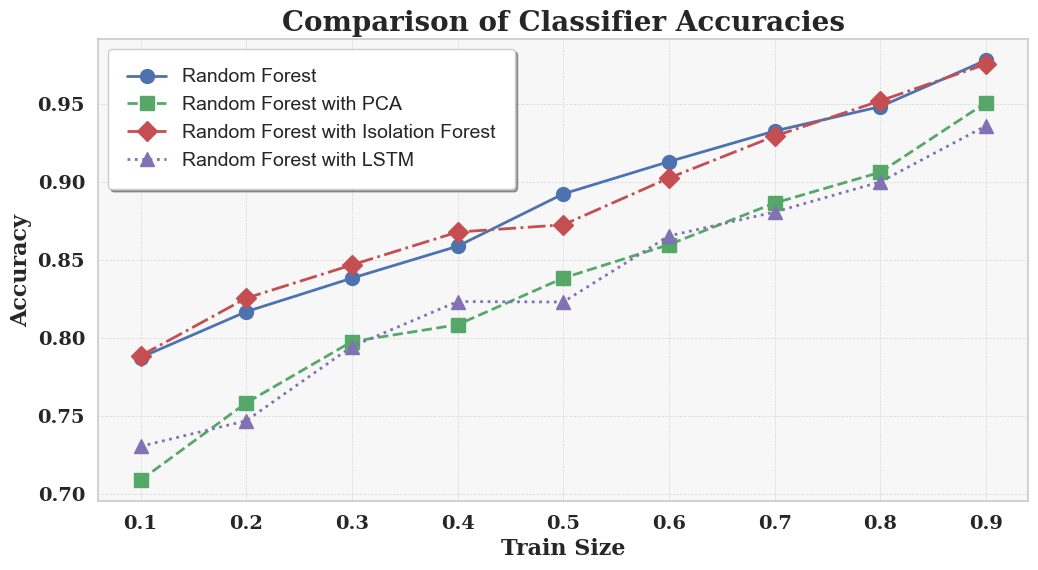

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

plt.plot(train_sizes, accuracies_rf, marker='o', label='Random Forest', linestyle='-', color='b', markersize=10, linewidth=2)
plt.plot(train_sizes, accuracies_pca, marker='s', label='Random Forest with PCA', linestyle='--', color='g', markersize=10, linewidth=2)
plt.plot(train_sizes, accuracies_isolation, marker='D', label='Random Forest with Isolation Forest', linestyle='-.', color='r', markersize=10, linewidth=2)
plt.plot(train_sizes, accuracies_lstm, marker='^', label='Random Forest with LSTM', linestyle=':', color='m', markersize=10, linewidth=2)

plt.title('Comparison of Classifier Accuracies', fontsize=20, fontweight='bold', family='serif')
plt.xlabel('Train Size', fontsize=16, fontweight='bold', family='serif')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold', family='serif')
plt.xticks(fontsize=14, fontweight='bold', family='serif')
plt.yticks(fontsize=14, fontweight='bold', family='serif')
plt.legend(loc='best', fontsize=14, frameon=True, fancybox=True, shadow=True, borderpad=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().set_facecolor('#f7f7f7')
plt.show()


In [15]:
joblib.dump(model_rf, '6_Random_Forest_Model.joblib')
joblib.dump(scaler, '6_Scaler.joblib')

['6_Scaler.joblib']